In [1]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:

# Define paths
zip_path = "/content/drive/My Drive/Decks.zip"  # Change this
extract_path = "/content/unzipped_folder"  # Destination folder in Colab

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List extracted files
print("Unzipping done! Extracted files:")
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))



Unzipping done! Extracted files:
/content/unzipped_folder/Decks/.DS_Store
/content/unzipped_folder/Decks/Non-cracked/7010-210.jpg
/content/unzipped_folder/Decks/Non-cracked/7023-103.jpg
/content/unzipped_folder/Decks/Non-cracked/7041-145.jpg
/content/unzipped_folder/Decks/Non-cracked/7049-58.jpg
/content/unzipped_folder/Decks/Non-cracked/7047-229.jpg
/content/unzipped_folder/Decks/Non-cracked/7039-44.jpg
/content/unzipped_folder/Decks/Non-cracked/7049-40.jpg
/content/unzipped_folder/Decks/Non-cracked/7026-252.jpg
/content/unzipped_folder/Decks/Non-cracked/7032-44.jpg
/content/unzipped_folder/Decks/Non-cracked/7057-205.jpg
/content/unzipped_folder/Decks/Non-cracked/7004-222.jpg
/content/unzipped_folder/Decks/Non-cracked/7034-53.jpg
/content/unzipped_folder/Decks/Non-cracked/7014-28.jpg
/content/unzipped_folder/Decks/Non-cracked/7041-20.jpg
/content/unzipped_folder/Decks/Non-cracked/7007-159.jpg
/content/unzipped_folder/Decks/Non-cracked/7020-250.jpg
/content/unzipped_folder/Decks/Non-cr

Removed: /content/unzipped_folder/Decks/.DS_Store
✅ Cleaning Done
Found 10896 images belonging to 2 classes.
Found 2724 images belonging to 2 classes.
Class Indices: {'Cracked': 0, 'Non-cracked': 1}
Label distribution in batch: {np.float32(0.0): np.int64(4), np.float32(1.0): np.int64(28)}


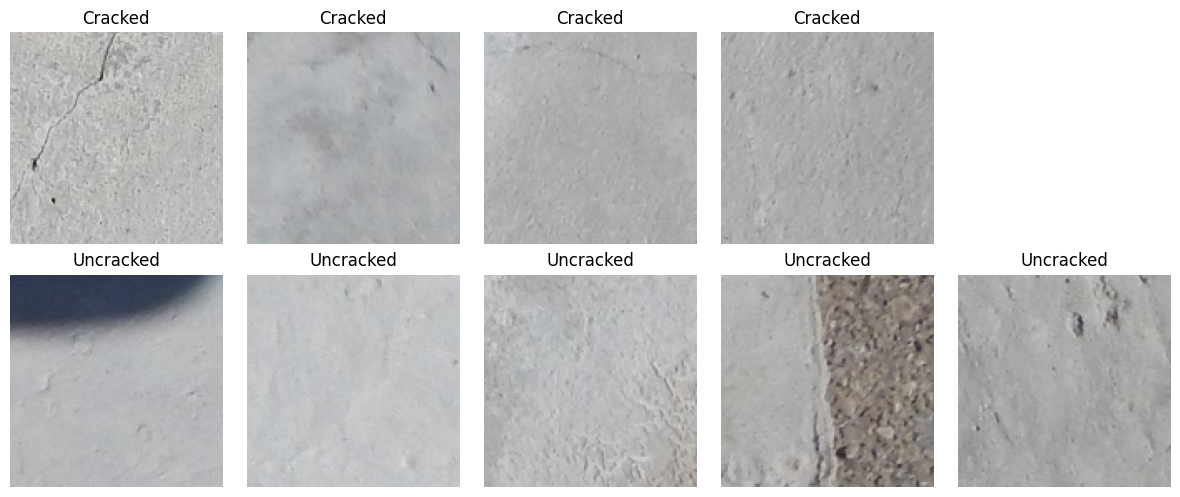


ANOVA Test: F=0.3756, P=0.5446
=> No significant difference


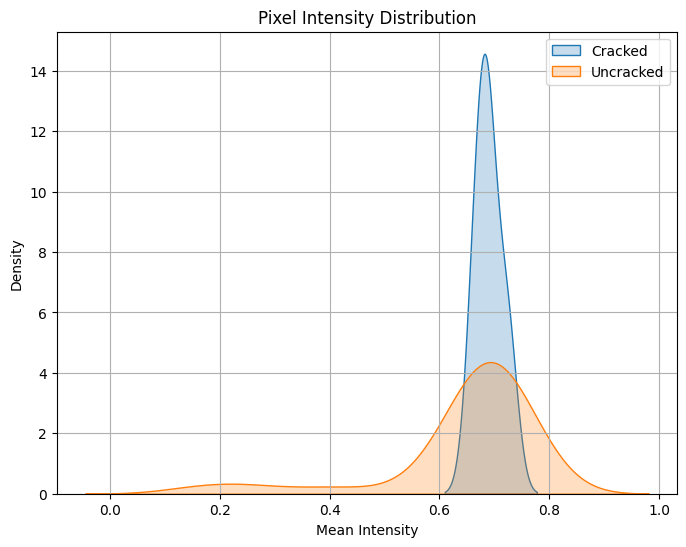

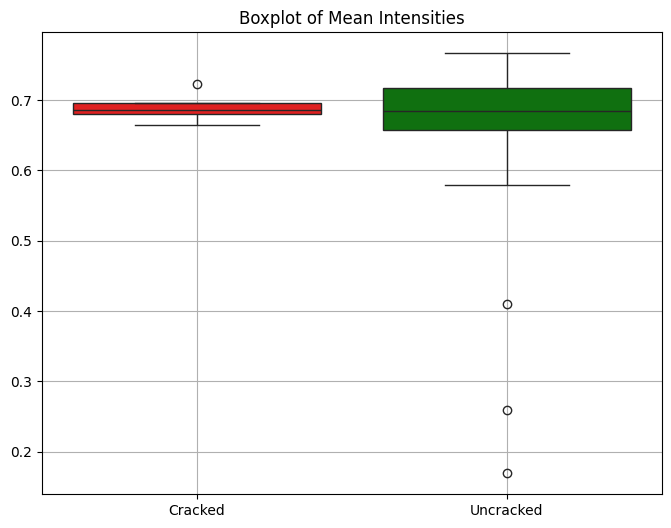

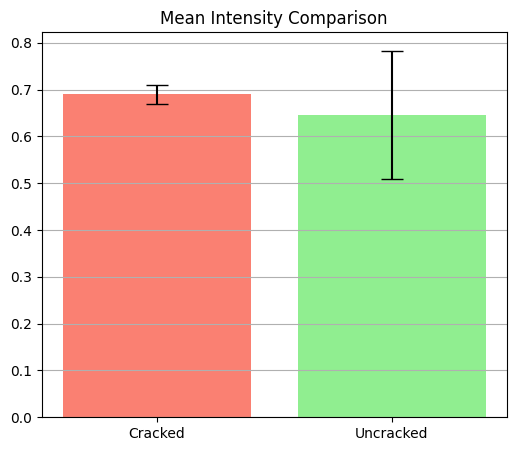


Mock F1 Score: 0.6818


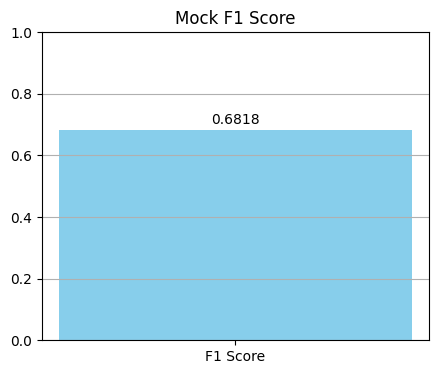

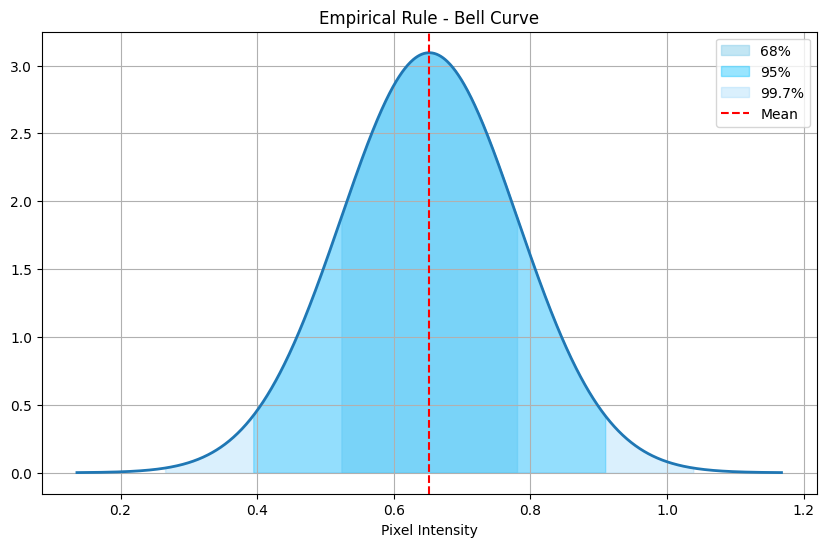


Chi-Square Test:
Chi2 = 0.2857, P = 0.5930
=> No significant association


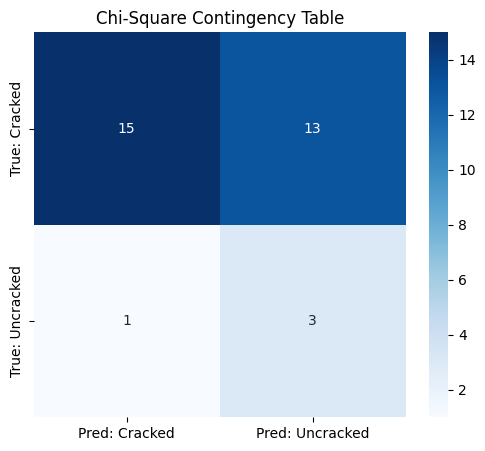

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import f1_score
from scipy.stats import f_oneway, norm, chi2_contingency
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. Define Paths and Parameters ---
base_dir = "/content/unzipped_folder/Decks"  # Updated path
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# --- 2. Clean Non-Image Files ---
def is_image_valid(filepath):
    try:
        img = Image.open(filepath)
        img.verify()
        return True
    except (UnidentifiedImageError, IOError):
        return False

def clean_directory(directory):
    removed = 0
    for root, _, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(root, file)
            if not is_image_valid(filepath):
                print(f"Removed: {filepath}")
                os.remove(filepath)
                removed += 1
    print("✅ Cleaning Done" if removed > 0 else "✅ No corrupt files found.")

clean_directory(base_dir)

# --- 3. Load Dataset ---
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=True
)

print("Class Indices:", train_generator.class_indices)

# --- 4. Fetch a Batch with Both Classes ---
found_cracked = False
for _ in range(10):  # Try 10 times
    X_batch, y_batch = next(train_generator)
    unique_classes = np.unique(y_batch)
    print("Label distribution in batch:", {label: np.sum(y_batch == label) for label in unique_classes})
    if len(unique_classes) > 1:
        found_cracked = True
        break

if not found_cracked:
    raise ValueError("No batch found with both cracked and uncracked images.")

# --- 5. Separate Classes ---
cracked_data = [(img, int(label)) for img, label in zip(X_batch, y_batch) if label == 0]
uncracked_data = [(img, int(label)) for img, label in zip(X_batch, y_batch) if label == 1]

# --- 6. Display Sample Images ---
plt.figure(figsize=(12, 5))
for i in range(min(5, len(cracked_data))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(cracked_data[i][0])
    plt.title("Cracked")
    plt.axis('off')

for i in range(min(5, len(uncracked_data))):
    plt.subplot(2, 5, i + 6)
    plt.imshow(uncracked_data[i][0])
    plt.title("Uncracked")
    plt.axis('off')

plt.tight_layout()
plt.show()

# --- 7. Intensity Analysis ---
cracked_means = [np.mean(img) for img, _ in cracked_data]
uncracked_means = [np.mean(img) for img, _ in uncracked_data]

# --- 8. ANOVA Test ---
f_stat, p_val = f_oneway(cracked_means, uncracked_means)
print(f"\nANOVA Test: F={f_stat:.4f}, P={p_val:.4f}")
print("=> Significant difference" if p_val < 0.05 else "=> No significant difference")

# --- 9. KDE Plot ---
plt.figure(figsize=(8, 6))
sns.kdeplot(cracked_means, label="Cracked", fill=True)
sns.kdeplot(uncracked_means, label="Uncracked", fill=True)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Mean Intensity")
plt.legend()
plt.grid(True)
plt.show()

# --- 10. Box + Bar Plot ---
plt.figure(figsize=(8, 6))
sns.boxplot(data=[cracked_means, uncracked_means], palette=["red", "green"])
plt.xticks([0, 1], ["Cracked", "Uncracked"])
plt.title("Boxplot of Mean Intensities")
plt.grid(True)
plt.show()

# Bar chart
cracked_mean, cracked_std = np.mean(cracked_means), np.std(cracked_means)
uncracked_mean, uncracked_std = np.mean(uncracked_means), np.std(uncracked_means)

plt.figure(figsize=(6, 5))
plt.bar(["Cracked", "Uncracked"], [cracked_mean, uncracked_mean],
        yerr=[cracked_std, uncracked_std], capsize=8, color=["salmon", "lightgreen"])
plt.title("Mean Intensity Comparison")
plt.grid(axis='y')
plt.show()

# --- 11. Mock F1 Score ---
all_data = cracked_data + uncracked_data
np.random.shuffle(all_data)
y_true = [label for _, label in all_data]
y_pred = np.random.choice([0, 1], size=len(y_true))  # Simulated predictions

f1 = f1_score(y_true, y_pred)
print(f"\nMock F1 Score: {f1:.4f}")

# --- F1 Score Plot ---
plt.figure(figsize=(5, 4))
bars = plt.bar(["F1 Score"], [f1], color='skyblue')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{f1:.4f}", ha='center')
plt.ylim(0, 1)
plt.title("Mock F1 Score")
plt.grid(axis='y')
plt.show()

# --- 12. Bell Curve ---
all_means = cracked_means + uncracked_means
mu, sigma = np.mean(all_means), np.std(all_means)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10, 6))
plt.plot(x, y, lw=2)
plt.fill_between(x, y, where=(x >= mu - sigma) & (x <= mu + sigma), color='skyblue', alpha=0.5, label='68%')
plt.fill_between(x, y, where=(x >= mu - 2*sigma) & (x <= mu + 2*sigma), color='deepskyblue', alpha=0.4, label='95%')
plt.fill_between(x, y, where=(x >= mu - 3*sigma) & (x <= mu + 3*sigma), color='lightskyblue', alpha=0.3, label='99.7%')
plt.axvline(mu, color='red', linestyle='--', label='Mean')
plt.title("Empirical Rule - Bell Curve")
plt.xlabel("Pixel Intensity")
plt.legend()
plt.grid(True)
plt.show()

# --- 13. Chi-Square Test ---
true = np.array(y_true)
pred = np.array(y_pred)

table = np.array([
    [np.sum((true == 1) & (pred == 1)), np.sum((true == 1) & (pred == 0))],
    [np.sum((true == 0) & (pred == 1)), np.sum((true == 0) & (pred == 0))]
])

chi2, p, dof, expected = chi2_contingency(table)
print("\nChi-Square Test:")
print(f"Chi2 = {chi2:.4f}, P = {p:.4f}")
print("=> Significant association" if p < 0.05 else "=> No significant association")

# --- Heatmap ---
plt.figure(figsize=(6, 5))
sns.heatmap(table, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: Cracked", "Pred: Uncracked"],
            yticklabels=["True: Cracked", "True: Uncracked"])
plt.title("Chi-Square Contingency Table")
plt.show()
